In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## baseline spec for classifier

In [2]:
df4 = pd.read_pickle('../data/df4_with_regions.pkl')

In [4]:
df4.head()

,BUS_SVC_NUM,CRD_NUM,DEST_LOC_ID_NUM,ENTRY_DT,ENTRY_TM,EXIT_DT,EXIT_TM,JRNY_ID_NUM,ORIG_LOC_ID_NUM,RIDE_DISC_AMT,...,final_termination_flag_spatial,final_termination_reason_spatial,final_termination_flag_spatial_nodist,final_termination_reason_spatial_nodist,is_same_journey_final,is_same_journey_final_nodist,final_journey_seq,orig_region,dest_region,house_area
0,45.0,100006223599,3968.0,2025-02-12,2025-02-12 06:49:58,2025-02-12,2025-02-12 07:00:33,110715426253,4009.0,0.0,...,False,candidate_transfer,False,candidate_transfer,True,True,0,HOUGANG,SERANGOON,HOUGANG
1,NaN,100006223599,109.0,2025-02-12,2025-02-12 07:01:53,2025-02-12,2025-02-12 07:10:18,110713956734,106.0,0.5,...,True,return_or_intermediate | exceeds_total_allowance,True,return_or_intermediate | exceeds_total_allowance,False,False,0,SERANGOON,KALLANG,HOUGANG
2,NaN,100006223599,106.0,2025-02-12,2025-02-12 15:21:06,2025-02-12,2025-02-12 15:32:56,110713665019,109.0,0.0,...,False,candidate_transfer,False,candidate_transfer,True,True,1,KALLANG,SERANGOON,HOUGANG
3,45.0,100006223599,4008.0,2025-02-12,2025-02-12 15:42:15,2025-02-12,2025-02-12 15:53:18,110714355046,3967.0,0.0,...,True,last_stage | null_time_gap,True,last_stage | null_time_gap,False,False,1,SERANGOON,HOUGANG,HOUGANG
4,382.0,130013244516,6927.0,2025-02-12,2025-02-12 08:45:07,2025-02-12,2025-02-12 08:59:01,110713628234,5953.0,0.0,...,False,candidate_transfer,False,candidate_transfer,True,True,0,PUNGGOL,PUNGGOL,PUNGGOL


In [7]:
print(df4.columns.tolist())

['BUS_SVC_NUM', 'CRD_NUM', 'DEST_LOC_ID_NUM', 'ENTRY_DT', 'ENTRY_TM', 'EXIT_DT', 'EXIT_TM', 'JRNY_ID_NUM', 'ORIG_LOC_ID_NUM', 'RIDE_DISC_AMT', 'RIDE_DIST_KM_CNT', 'RIDE_FARE_AMT', 'RIDE_ID_NUM', 'RIDE_MIN_CNT', 'PATRON_CATG_ID_NUM', 'TRNSPT_MODE_CD', 'DEST_STATION_NAME', 'DEST_MRK_ID_NUM', 'DEST_LATITUDE', 'DEST_LONGITUDE', 'DEST_Travel_Type', 'ORIG_STATION_NAME', 'ORIG_MRK_ID_NUM', 'ORIG_LATITUDE', 'ORIG_LONGITUDE', 'ORIG_Travel_Type', 'next_orig_lat', 'next_orig_lon', 'next_orig_station', 'walk_distance', 'PATRON_CATG_DESC_TXT', 'walking_speed_ms', 'service_day', 'next_ENTRY_TM', 'next_ORIG_LOC_ID_NUM', 'next_BUS_SVC_NUM', 'next_TRNSPT_MODE_CD_x', 'is_last_stage', 'missing_info', 'same_bus_service', 'same_station_consecutive', 'return_or_intermediate', 'journey_termination_flag', 'journey_termination_reason', 'full_journey_seq', 'orig_journey_station', 'entry_journey_tm', 'dest_journey_station', 'exit_journey_tm', 'next_orig_journey_location', 'walk_to_next_journey_distance', 'time_g

- We compare each transfer window size against our rule-based classifier, which serves as the ground truth proxy for what constitutes a legitimate journey
- The comparison is done at the ride-pair level — each row represents a consecutive pair of rides by the same commuter
- Wrongly split: classifier says the pair is a transfer (same journey), but the window says the gap is too long and breaks them apart → commuter gets overcharged
- Wrongly merged: classifier says the pair is a new journey, but the window links them as a transfer → commuter incorrectly receives a transfer fare discount
- We vary the bus transfer window from 20 to 55 minutes in 5-minute increments, while holding train-to-train transfers fixed at 15 minutes
- For each window size, wrongly split and wrongly merged rates are computed separately for Adult, Student, and Senior Citizen
- As the window increases, wrongly split decreases (window becomes more permissive) and wrongly merged increases (window starts linking rides that should be separate)
- The goal is to identify the window size that best balances these two types of misclassification across patron groups

In [3]:
# how many ride pairs have missing time_gap_mins before filtering
total_before = len(df4[df4['is_last_stage'] == False])
missing_time_gap = df4[df4['is_last_stage'] == False]['time_gap_mins'].isna().sum()

print(f"Total ride pairs (excl last stage): {total_before:,}")
print(f"Missing time_gap_mins: {missing_time_gap:,}")
print(f"Missing %: {missing_time_gap / total_before * 100:.2f}%")

# how many unique card numbers affected
missing_crds = df4[
    (df4['is_last_stage'] == False) &
    (df4['time_gap_mins'].isna())
]['CRD_NUM'].nunique()
total_crds = df4['CRD_NUM'].nunique()

print(f"\nCard numbers with at least one missing pair: {missing_crds:,}")
print(f"Total card numbers: {total_crds:,}")
print(f"Affected card %: {missing_crds / total_crds * 100:.2f}%")

Total ride pairs (excl last stage): 5,205,195
Missing time_gap_mins: 240,983
Missing %: 4.63%

Card numbers with at least one missing pair: 28,112
Total card numbers: 2,459,161
Affected card %: 1.14%


In [4]:
# find card numbers with any missing time_gap_mins (excluding last stage)
crds_with_missing = df4[
    (df4['is_last_stage'] == False) &
    (df4['time_gap_mins'].isna())
]['CRD_NUM'].unique()

# filter once upfront — drop entire card number if any pair has missing data
df_pairs = df4[
    (df4['is_last_stage'] == False) &
    (~df4['CRD_NUM'].isin(crds_with_missing)) &     # remove card numbers with any missing pair
    (df4['PATRON_CATG_DESC_TXT'].notna())            # remove unknown patron category
].copy()

print(f"Card numbers removed: {len(crds_with_missing):,}")
print(f"Total ride pairs remaining: {len(df_pairs):,}")
print(df_pairs['mode_pair'].value_counts())

Card numbers removed: 28,112
Total ride pairs remaining: 4,747,388
mode_pair
bus_bus        1701748
train_train    1185721
train_bus       929996
bus_train       929923
Name: count, dtype: int64


In [ ]:
''' WITHOUT FILTERING OUT CARD NUM WITH MISSING INFO. only filters out the row
# filter once upfront — only valid ride pairs
df_pairs = df4[
    (df4['is_last_stage'] == False) &       # must have a next ride
    (df4['time_gap_mins'].notna()) &         # window needs a time gap to evaluate
    (df4['PATRON_CATG_DESC_TXT'].notna())    # remove unknown patron category
].copy()

print(f"Total ride pairs: {len(df_pairs):,}")
print(df_pairs['mode_pair'].value_counts())'''

Total ride pairs: 4,810,892
mode_pair
bus_bus        1728727
train_train    1196989
train_bus       947278
bus_train       937898
Name: count, dtype: int64


In [5]:
# ── Cell 2: window comparison loop ───────────────────────────────────────────

results = []

# classifier verdict is fixed across all windows
classifier_says_transfer = (df_pairs['final_termination_flag_spatial'] == False)

for w in range(20, 60, 5):

    window = df_pairs['mode_pair'].map(
        lambda x: 15 if x == 'train_train' else w
    )

    window_says_transfer = (df_pairs['time_gap_mins'] <= window)

    wrongly_split  = classifier_says_transfer & ~window_says_transfer
    wrongly_merged = ~classifier_says_transfer & window_says_transfer

    results.append({
        'window_mins':             w,
        'patron':                  'Overall',
        'wrongly_split_n':         wrongly_split.sum(),
        'wrongly_merged_n':        wrongly_merged.sum(),
        'wrongly_split_pct':       wrongly_split.mean() * 100,
        'wrongly_merged_pct':      wrongly_merged.mean() * 100,
        'wrongly_split_cond_pct':  (wrongly_split[classifier_says_transfer].mean() * 100) if classifier_says_transfer.sum() > 0 else 0,
        'wrongly_merged_cond_pct': (wrongly_merged[~classifier_says_transfer].mean() * 100) if (~classifier_says_transfer).sum() > 0 else 0,
    })

    for patron in df_pairs['PATRON_CATG_DESC_TXT'].unique():
        mask                = df_pairs['PATRON_CATG_DESC_TXT'] == patron
        clf_transfer_mask   = classifier_says_transfer[mask]
        wrongly_split_mask  = wrongly_split[mask]
        wrongly_merged_mask = wrongly_merged[mask]

        results.append({
            'window_mins':             w,
            'patron':                  patron,
            'wrongly_split_n':         wrongly_split_mask.sum(),
            'wrongly_merged_n':        wrongly_merged_mask.sum(),
            'wrongly_split_pct':       wrongly_split_mask.mean() * 100,
            'wrongly_merged_pct':      wrongly_merged_mask.mean() * 100,
            'wrongly_split_cond_pct':  (wrongly_split_mask[clf_transfer_mask].mean() * 100) if clf_transfer_mask.sum() > 0 else 0,
            'wrongly_merged_cond_pct': (wrongly_merged_mask[~clf_transfer_mask].mean() * 100) if (~clf_transfer_mask).sum() > 0 else 0,
        })

results_df = pd.DataFrame(results)
print(results_df)

    window_mins          patron  wrongly_split_n  wrongly_merged_n  \
0            20         Overall             7101            515890   
1            20         Student              339             57407   
2            20           Adult             3775            326405   
3            20  Senior Citizen             2987            132078   
4            25         Overall             1658            583754   
5            25         Student               56             62753   
6            25           Adult              854            370795   
7            25  Senior Citizen              748            150206   
8            30         Overall              656            640618   
9            30         Student               21             66862   
10           30           Adult              420            406275   
11           30  Senior Citizen              215            167481   
12           35         Overall              461            689777   
13           35     

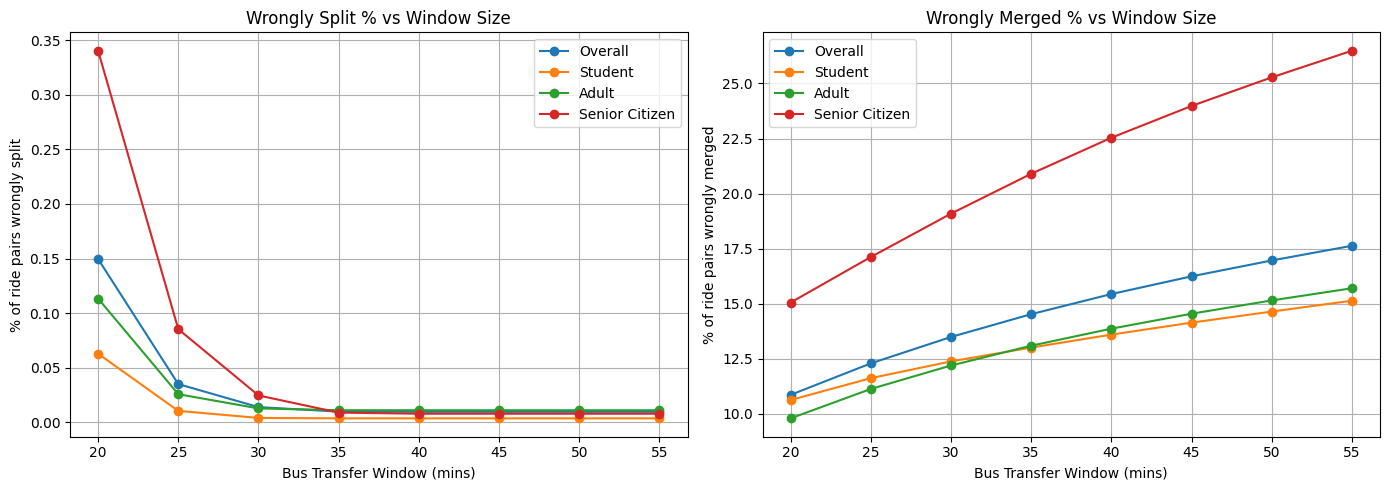

In [6]:
# ── Cell 3: visualise ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for patron in results_df['patron'].unique():
    sub = results_df[results_df['patron'] == patron].sort_values('window_mins')
    axes[0].plot(sub['window_mins'], sub['wrongly_split_pct'],  marker='o', label=patron)
    axes[1].plot(sub['window_mins'], sub['wrongly_merged_pct'], marker='o', label=patron)

axes[0].set_title('Wrongly Split % vs Window Size')
axes[0].set_xlabel('Bus Transfer Window (mins)')
axes[0].set_ylabel('% of ride pairs wrongly split')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Wrongly Merged % vs Window Size')
axes[1].set_xlabel('Bus Transfer Window (mins)')
axes[1].set_ylabel('% of ride pairs wrongly merged')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [7]:
# classifier verdict is fixed across all windows
classifier_says_transfer = (df_pairs['final_termination_flag_spatial'] == False)

baseline_results = []

for w in range(20, 60, 5):

    window = df_pairs['mode_pair'].map(
        lambda x: 15 if x == 'train_train' else w
    )

    window_says_transfer = (df_pairs['time_gap_mins'] <= window)

    wrongly_split  = classifier_says_transfer & ~window_says_transfer
    wrongly_merged = ~classifier_says_transfer & window_says_transfer

    baseline_results.append({
        'spec':                     'baseline',
        'window_mins':              w,
        'patron':                   'Overall',
        'classifier_transfer_n':    classifier_says_transfer.sum(),
        'classifier_new_journey_n': (~classifier_says_transfer).sum(),
        'window_transfer_n':        window_says_transfer.sum(),
        'window_new_journey_n':     (~window_says_transfer).sum(),
        'wrongly_split_n':          wrongly_split.sum(),
        'wrongly_merged_n':         wrongly_merged.sum(),
        'wrongly_split_pct':        wrongly_split.mean() * 100,
        'wrongly_merged_pct':       wrongly_merged.mean() * 100,
        'wrongly_split_cond_pct':   (wrongly_split[classifier_says_transfer].mean() * 100) if classifier_says_transfer.sum() > 0 else 0,
        'wrongly_merged_cond_pct':  (wrongly_merged[~classifier_says_transfer].mean() * 100) if (~classifier_says_transfer).sum() > 0 else 0,
    })

    for patron in df_pairs['PATRON_CATG_DESC_TXT'].unique():
        mask                = df_pairs['PATRON_CATG_DESC_TXT'] == patron
        clf_transfer_mask   = classifier_says_transfer[mask]
        wrongly_split_mask  = wrongly_split[mask]
        wrongly_merged_mask = wrongly_merged[mask]

        baseline_results.append({
            'spec':                     'baseline',
            'window_mins':              w,
            'patron':                   patron,
            'classifier_transfer_n':    clf_transfer_mask.sum(),
            'classifier_new_journey_n': (~clf_transfer_mask).sum(),
            'window_transfer_n':        window_says_transfer[mask].sum(),
            'window_new_journey_n':     (~window_says_transfer[mask]).sum(),
            'wrongly_split_n':          wrongly_split_mask.sum(),
            'wrongly_merged_n':         wrongly_merged_mask.sum(),
            'wrongly_split_pct':        wrongly_split_mask.mean() * 100,
            'wrongly_merged_pct':       wrongly_merged_mask.mean() * 100,
            'wrongly_split_cond_pct':   (wrongly_split_mask[clf_transfer_mask].mean() * 100) if clf_transfer_mask.sum() > 0 else 0,
            'wrongly_merged_cond_pct':  (wrongly_merged_mask[~clf_transfer_mask].mean() * 100) if (~clf_transfer_mask).sum() > 0 else 0,
        })

results_baseline_df = pd.DataFrame(baseline_results)
print(results_baseline_df.to_string())

        spec  window_mins          patron  classifier_transfer_n  classifier_new_journey_n  window_transfer_n  window_new_journey_n  wrongly_split_n  wrongly_merged_n  wrongly_split_pct  wrongly_merged_pct  wrongly_split_cond_pct  wrongly_merged_cond_pct
0   baseline           20         Overall                1578616                   3168772            2087405               2659983             7101            515890           0.149577           10.866818                0.449824                16.280439
1   baseline           20         Student                 187869                    351987             244937                294919              339             57407           0.062795           10.633762                0.180445                16.309409
2   baseline           20           Adult                1134326                   2195948            1456956               1873318             3775            326405           0.113354            9.801145                0.332797      

In [8]:
# ── Marginal welfare table — baseline ────────────────────────────────────────
# for each window step w → w+5, find pairs newly linked by the larger window
# marginal benefit = newly linked where classifier says transfer (legitimate rescue)
# marginal cost    = newly linked where classifier says new journey (illegitimate link)

marginal_baseline_results = []
windows = list(range(20, 60, 5))

for i in range(len(windows) - 1):
    w_from = windows[i]
    w_to   = windows[i + 1]

    window_from = df_pairs['mode_pair'].map(lambda x: 15 if x == 'train_train' else w_from)
    window_to   = df_pairs['mode_pair'].map(lambda x: 15 if x == 'train_train' else w_to)

    linked_by_from = df_pairs['time_gap_mins'] <= window_from
    linked_by_to   = df_pairs['time_gap_mins'] <= window_to
    newly_linked   = linked_by_to & ~linked_by_from

    marginal_benefit = newly_linked & classifier_says_transfer
    marginal_cost    = newly_linked & ~classifier_says_transfer

    marginal_baseline_results.append({
        'spec':               'baseline',
        'window_from':        w_from,
        'window_to':          w_to,
        'patron':             'Overall',
        'newly_linked_n':     newly_linked.sum(),
        'marginal_benefit_n': marginal_benefit.sum(),
        'marginal_cost_n':    marginal_cost.sum(),
    })

    for patron in df_pairs['PATRON_CATG_DESC_TXT'].unique():
        mask = df_pairs['PATRON_CATG_DESC_TXT'] == patron
        marginal_baseline_results.append({
            'spec':               'baseline',
            'window_from':        w_from,
            'window_to':          w_to,
            'patron':             patron,
            'newly_linked_n':     newly_linked[mask].sum(),
            'marginal_benefit_n': marginal_benefit[mask].sum(),
            'marginal_cost_n':    marginal_cost[mask].sum(),
        })

marginal_baseline_df = pd.DataFrame(marginal_baseline_results)
print(marginal_baseline_df.to_string())

        spec  window_from  window_to          patron  newly_linked_n  marginal_benefit_n  marginal_cost_n
0   baseline           20         25         Overall           73307                5443            67864
1   baseline           20         25         Student            5629                 283             5346
2   baseline           20         25           Adult           47311                2921            44390
3   baseline           20         25  Senior Citizen           20367                2239            18128
4   baseline           25         30         Overall           57866                1002            56864
5   baseline           25         30         Student            4144                  35             4109
6   baseline           25         30           Adult           35914                 434            35480
7   baseline           25         30  Senior Citizen           17808                 533            17275
8   baseline           30         35         O

In [9]:
# free baseline df4 from memory before loading next spec
del df4, df_pairs
import gc
gc.collect()


0

## strict spec for classifier

In [10]:
# load strict classifier
df4_strict = pd.read_pickle('../data/df4_strict_with_regions.pkl')

In [11]:
# find card numbers with any missing time_gap_mins
crds_with_missing_strict = df4_strict[
    (df4_strict['is_last_stage'] == False) &
    (df4_strict['time_gap_mins'].isna())
]['CRD_NUM'].unique()

# filter to valid ride pairs
df_pairs_strict = df4_strict[
    (df4_strict['is_last_stage'] == False) &
    (~df4_strict['CRD_NUM'].isin(crds_with_missing_strict)) &
    (df4_strict['PATRON_CATG_DESC_TXT'].notna())
].copy()

print(f"Strict — total ride pairs: {len(df_pairs_strict):,}")
print(df_pairs_strict['mode_pair'].value_counts())

Strict — total ride pairs: 4,747,388
mode_pair
bus_bus        1701748
train_train    1185721
train_bus       929996
bus_train       929923
Name: count, dtype: int64


In [12]:
classifier_says_transfer_strict = (df_pairs_strict['final_termination_flag_spatial'] == False)

strict_results = []

for w in range(20, 60, 5):

    window = df_pairs_strict['mode_pair'].map(
        lambda x: 15 if x == 'train_train' else w
    )

    window_says_transfer = (df_pairs_strict['time_gap_mins'] <= window)

    wrongly_split  = classifier_says_transfer_strict & ~window_says_transfer
    wrongly_merged = ~classifier_says_transfer_strict & window_says_transfer

    strict_results.append({
        'spec':                     'strict',
        'window_mins':              w,
        'patron':                   'Overall',
        'classifier_transfer_n':    classifier_says_transfer_strict.sum(),
        'classifier_new_journey_n': (~classifier_says_transfer_strict).sum(),
        'window_transfer_n':        window_says_transfer.sum(),
        'window_new_journey_n':     (~window_says_transfer).sum(),
        'wrongly_split_n':          wrongly_split.sum(),
        'wrongly_merged_n':         wrongly_merged.sum(),
        'wrongly_split_pct':        wrongly_split.mean() * 100,
        'wrongly_merged_pct':       wrongly_merged.mean() * 100,
        'wrongly_split_cond_pct':   (wrongly_split[classifier_says_transfer_strict].mean() * 100) if classifier_says_transfer_strict.sum() > 0 else 0,
        'wrongly_merged_cond_pct':  (wrongly_merged[~classifier_says_transfer_strict].mean() * 100) if (~classifier_says_transfer_strict).sum() > 0 else 0,
    })

    for patron in df_pairs_strict['PATRON_CATG_DESC_TXT'].unique():
        mask                = df_pairs_strict['PATRON_CATG_DESC_TXT'] == patron
        clf_transfer_mask   = classifier_says_transfer_strict[mask]
        wrongly_split_mask  = wrongly_split[mask]
        wrongly_merged_mask = wrongly_merged[mask]

        strict_results.append({
            'spec':                     'strict',
            'window_mins':              w,
            'patron':                   patron,
            'classifier_transfer_n':    clf_transfer_mask.sum(),
            'classifier_new_journey_n': (~clf_transfer_mask).sum(),
            'window_transfer_n':        window_says_transfer[mask].sum(),
            'window_new_journey_n':     (~window_says_transfer[mask]).sum(),
            'wrongly_split_n':          wrongly_split_mask.sum(),
            'wrongly_merged_n':         wrongly_merged_mask.sum(),
            'wrongly_split_pct':        wrongly_split_mask.mean() * 100,
            'wrongly_merged_pct':       wrongly_merged_mask.mean() * 100,
            'wrongly_split_cond_pct':   (wrongly_split_mask[clf_transfer_mask].mean() * 100) if clf_transfer_mask.sum() > 0 else 0,
            'wrongly_merged_cond_pct':  (wrongly_merged_mask[~clf_transfer_mask].mean() * 100) if (~clf_transfer_mask).sum() > 0 else 0,
        })

results_strict_df = pd.DataFrame(strict_results)
print(results_strict_df.to_string())

      spec  window_mins          patron  classifier_transfer_n  classifier_new_journey_n  window_transfer_n  window_new_journey_n  wrongly_split_n  wrongly_merged_n  wrongly_split_pct  wrongly_merged_pct  wrongly_split_cond_pct  wrongly_merged_cond_pct
0   strict           20         Overall                1510119                   3237269            2087405               2659983             2752            580038           0.057969           12.218045                0.182237                17.917510
1   strict           20         Student                 180562                    359294             244937                294919              125             64500           0.023154           11.947630                0.069228                17.951872
2   strict           20           Adult                1086785                   2243489            1456956               1873318             1402            371573           0.042099           11.157430                0.129004              

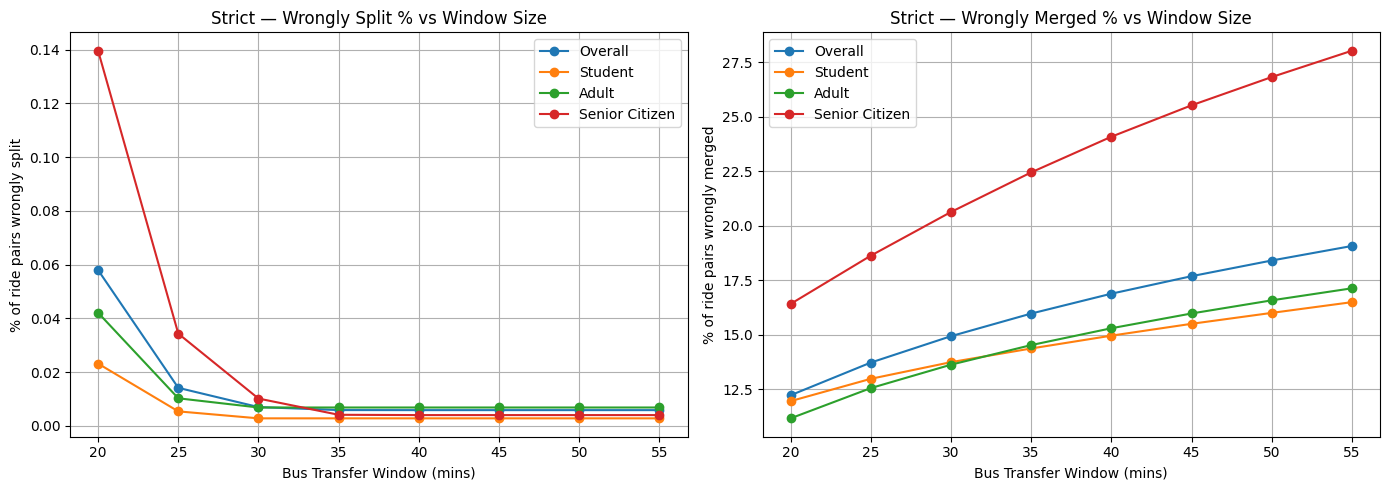

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for patron in results_strict_df['patron'].unique():
    sub = results_strict_df[results_strict_df['patron'] == patron].sort_values('window_mins')
    axes[0].plot(sub['window_mins'], sub['wrongly_split_pct'],  marker='o', label=patron)
    axes[1].plot(sub['window_mins'], sub['wrongly_merged_pct'], marker='o', label=patron)

axes[0].set_title('Strict — Wrongly Split % vs Window Size')
axes[0].set_xlabel('Bus Transfer Window (mins)')
axes[0].set_ylabel('% of ride pairs wrongly split')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Strict — Wrongly Merged % vs Window Size')
axes[1].set_xlabel('Bus Transfer Window (mins)')
axes[1].set_ylabel('% of ride pairs wrongly merged')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [14]:
# ── Marginal welfare table — strict ──────────────────────────────────────────

marginal_strict_results = []

for i in range(len(windows) - 1):
    w_from = windows[i]
    w_to   = windows[i + 1]

    window_from = df_pairs_strict['mode_pair'].map(lambda x: 15 if x == 'train_train' else w_from)
    window_to   = df_pairs_strict['mode_pair'].map(lambda x: 15 if x == 'train_train' else w_to)

    linked_by_from = df_pairs_strict['time_gap_mins'] <= window_from
    linked_by_to   = df_pairs_strict['time_gap_mins'] <= window_to
    newly_linked   = linked_by_to & ~linked_by_from

    marginal_benefit = newly_linked & classifier_says_transfer_strict
    marginal_cost    = newly_linked & ~classifier_says_transfer_strict

    marginal_strict_results.append({
        'spec':               'strict',
        'window_from':        w_from,
        'window_to':          w_to,
        'patron':             'Overall',
        'newly_linked_n':     newly_linked.sum(),
        'marginal_benefit_n': marginal_benefit.sum(),
        'marginal_cost_n':    marginal_cost.sum(),
    })

    for patron in df_pairs_strict['PATRON_CATG_DESC_TXT'].unique():
        mask = df_pairs_strict['PATRON_CATG_DESC_TXT'] == patron
        marginal_strict_results.append({
            'spec':               'strict',
            'window_from':        w_from,
            'window_to':          w_to,
            'patron':             patron,
            'newly_linked_n':     newly_linked[mask].sum(),
            'marginal_benefit_n': marginal_benefit[mask].sum(),
            'marginal_cost_n':    marginal_cost[mask].sum(),
        })

marginal_strict_df = pd.DataFrame(marginal_strict_results)
print(marginal_strict_df.to_string())

      spec  window_from  window_to          patron  newly_linked_n  marginal_benefit_n  marginal_cost_n
0   strict           20         25         Overall           73307                2081            71226
1   strict           20         25         Student            5629                  96             5533
2   strict           20         25           Adult           47311                1061            46250
3   strict           20         25  Senior Citizen           20367                 924            19443
4   strict           25         30         Overall           57866                 340            57526
5   strict           25         30         Student            4144                  14             4130
6   strict           25         30           Adult           35914                 114            35800
7   strict           25         30  Senior Citizen           17808                 212            17596
8   strict           30         35         Overall           493

## lenient spec for classifier

In [15]:
del df4_strict, df_pairs_strict
gc.collect()

9439

In [16]:
df4_lenient = pd.read_pickle('../data/df4_lenient_with_regions.pkl')

In [17]:
crds_with_missing_lenient = df4_lenient[
    (df4_lenient['is_last_stage'] == False) &
    (df4_lenient['time_gap_mins'].isna())
]['CRD_NUM'].unique()

df_pairs_lenient = df4_lenient[
    (df4_lenient['is_last_stage'] == False) &
    (~df4_lenient['CRD_NUM'].isin(crds_with_missing_lenient)) &
    (df4_lenient['PATRON_CATG_DESC_TXT'].notna())
].copy()

print(f"Lenient — total ride pairs: {len(df_pairs_lenient):,}")
print(df_pairs_lenient['mode_pair'].value_counts())

Lenient — total ride pairs: 4,747,388
mode_pair
bus_bus        1701748
train_train    1185721
train_bus       929996
bus_train       929923
Name: count, dtype: int64


In [18]:
classifier_says_transfer_lenient = (df_pairs_lenient['final_termination_flag_spatial'] == False)

lenient_results = []

for w in range(20, 60, 5):

    window = df_pairs_lenient['mode_pair'].map(
        lambda x: 15 if x == 'train_train' else w
    )

    window_says_transfer = (df_pairs_lenient['time_gap_mins'] <= window)

    wrongly_split  = classifier_says_transfer_lenient & ~window_says_transfer
    wrongly_merged = ~classifier_says_transfer_lenient & window_says_transfer

    lenient_results.append({
        'spec':                     'lenient',
        'window_mins':              w,
        'patron':                   'Overall',
        'classifier_transfer_n':    classifier_says_transfer_lenient.sum(),
        'classifier_new_journey_n': (~classifier_says_transfer_lenient).sum(),
        'window_transfer_n':        window_says_transfer.sum(),
        'window_new_journey_n':     (~window_says_transfer).sum(),
        'wrongly_split_n':          wrongly_split.sum(),
        'wrongly_merged_n':         wrongly_merged.sum(),
        'wrongly_split_pct':        wrongly_split.mean() * 100,
        'wrongly_merged_pct':       wrongly_merged.mean() * 100,
        'wrongly_split_cond_pct':   (wrongly_split[classifier_says_transfer_lenient].mean() * 100) if classifier_says_transfer_lenient.sum() > 0 else 0,
        'wrongly_merged_cond_pct':  (wrongly_merged[~classifier_says_transfer_lenient].mean() * 100) if (~classifier_says_transfer_lenient).sum() > 0 else 0,
    })

    for patron in df_pairs_lenient['PATRON_CATG_DESC_TXT'].unique():
        mask                = df_pairs_lenient['PATRON_CATG_DESC_TXT'] == patron
        clf_transfer_mask   = classifier_says_transfer_lenient[mask]
        wrongly_split_mask  = wrongly_split[mask]
        wrongly_merged_mask = wrongly_merged[mask]

        lenient_results.append({
            'spec':                     'lenient',
            'window_mins':              w,
            'patron':                   patron,
            'classifier_transfer_n':    clf_transfer_mask.sum(),
            'classifier_new_journey_n': (~clf_transfer_mask).sum(),
            'window_transfer_n':        window_says_transfer[mask].sum(),
            'window_new_journey_n':     (~window_says_transfer[mask]).sum(),
            'wrongly_split_n':          wrongly_split_mask.sum(),
            'wrongly_merged_n':         wrongly_merged_mask.sum(),
            'wrongly_split_pct':        wrongly_split_mask.mean() * 100,
            'wrongly_merged_pct':       wrongly_merged_mask.mean() * 100,
            'wrongly_split_cond_pct':   (wrongly_split_mask[clf_transfer_mask].mean() * 100) if clf_transfer_mask.sum() > 0 else 0,
            'wrongly_merged_cond_pct':  (wrongly_merged_mask[~clf_transfer_mask].mean() * 100) if (~clf_transfer_mask).sum() > 0 else 0,
        })

results_lenient_df = pd.DataFrame(lenient_results)
print(results_lenient_df.to_string())

       spec  window_mins          patron  classifier_transfer_n  classifier_new_journey_n  window_transfer_n  window_new_journey_n  wrongly_split_n  wrongly_merged_n  wrongly_split_pct  wrongly_merged_pct  wrongly_split_cond_pct  wrongly_merged_cond_pct
0   lenient           20         Overall                1627987                   3119401            2087405               2659983            16646            476064           0.350635           10.027914                1.022490                15.261392
1   lenient           20         Student                 192652                    347204             244937                294919              999             53284           0.185049            9.870039                0.518552                15.346597
2   lenient           20           Adult                1168539                   2161735            1456956               1873318             9390            297807           0.281959            8.942417                0.803568          

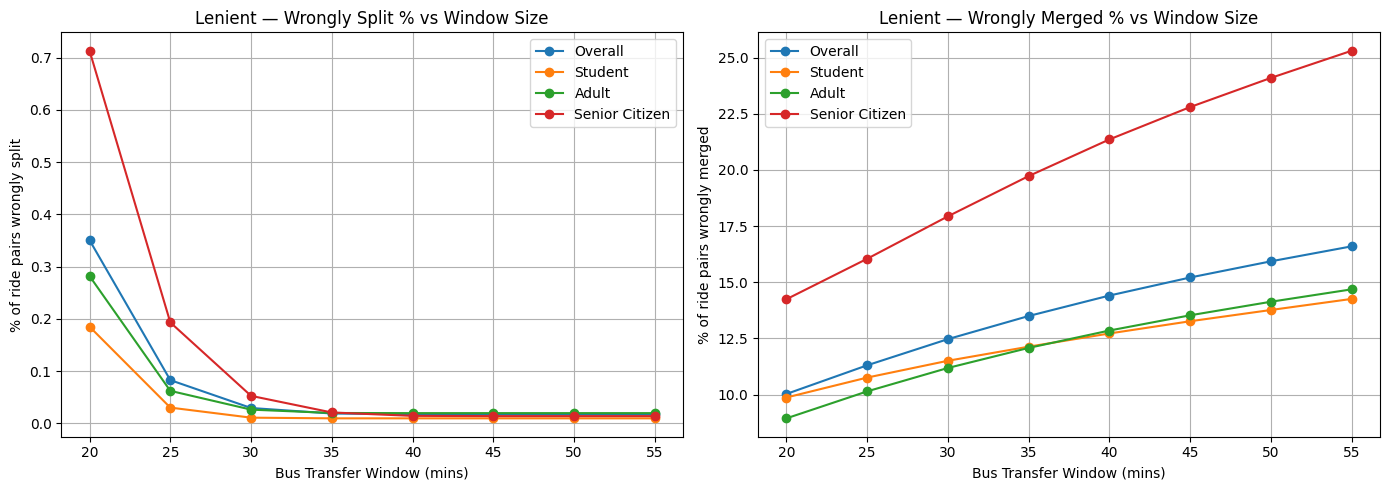

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for patron in results_lenient_df['patron'].unique():
    sub = results_lenient_df[results_lenient_df['patron'] == patron].sort_values('window_mins')
    axes[0].plot(sub['window_mins'], sub['wrongly_split_pct'],  marker='o', label=patron)
    axes[1].plot(sub['window_mins'], sub['wrongly_merged_pct'], marker='o', label=patron)

axes[0].set_title('Lenient — Wrongly Split % vs Window Size')
axes[0].set_xlabel('Bus Transfer Window (mins)')
axes[0].set_ylabel('% of ride pairs wrongly split')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Lenient — Wrongly Merged % vs Window Size')
axes[1].set_xlabel('Bus Transfer Window (mins)')
axes[1].set_ylabel('% of ride pairs wrongly merged')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [20]:
# ── Marginal welfare table — lenient ─────────────────────────────────────────

marginal_lenient_results = []

for i in range(len(windows) - 1):
    w_from = windows[i]
    w_to   = windows[i + 1]

    window_from = df_pairs_lenient['mode_pair'].map(lambda x: 15 if x == 'train_train' else w_from)
    window_to   = df_pairs_lenient['mode_pair'].map(lambda x: 15 if x == 'train_train' else w_to)

    linked_by_from = df_pairs_lenient['time_gap_mins'] <= window_from
    linked_by_to   = df_pairs_lenient['time_gap_mins'] <= window_to
    newly_linked   = linked_by_to & ~linked_by_from

    marginal_benefit = newly_linked & classifier_says_transfer_lenient
    marginal_cost    = newly_linked & ~classifier_says_transfer_lenient

    marginal_lenient_results.append({
        'spec':               'lenient',
        'window_from':        w_from,
        'window_to':          w_to,
        'patron':             'Overall',
        'newly_linked_n':     newly_linked.sum(),
        'marginal_benefit_n': marginal_benefit.sum(),
        'marginal_cost_n':    marginal_cost.sum(),
    })

    for patron in df_pairs_lenient['PATRON_CATG_DESC_TXT'].unique():
        mask = df_pairs_lenient['PATRON_CATG_DESC_TXT'] == patron
        marginal_lenient_results.append({
            'spec':               'lenient',
            'window_from':        w_from,
            'window_to':          w_to,
            'patron':             patron,
            'newly_linked_n':     newly_linked[mask].sum(),
            'marginal_benefit_n': marginal_benefit[mask].sum(),
            'marginal_cost_n':    marginal_cost[mask].sum(),
        })

marginal_lenient_df = pd.DataFrame(marginal_lenient_results)
print(marginal_lenient_df.to_string())

       spec  window_from  window_to          patron  newly_linked_n  marginal_benefit_n  marginal_cost_n
0   lenient           20         25         Overall           73307               12715            60592
1   lenient           20         25         Student            5629                 836             4793
2   lenient           20         25           Adult           47311                7317            39994
3   lenient           20         25  Senior Citizen           20367                4562            15805
4   lenient           25         30         Overall           57866                2534            55332
5   lenient           25         30         Student            4144                 104             4040
6   lenient           25         30           Adult           35914                1197            34717
7   lenient           25         30  Senior Citizen           17808                1233            16575
8   lenient           30         35         Overall    

In [21]:
del df4_lenient, df_pairs_lenient
gc.collect()

9439

## Combining all results

In [22]:
# combine all 3 specs into one df
final_results_df = pd.concat(
    [results_baseline_df, results_strict_df, results_lenient_df],
    ignore_index=True
)

final_results_df.to_csv('../data/welfare_results.csv', index=False)
print('Saved welfare_results.csv')
print(final_results_df.shape)

Saved welfare_results.csv
(96, 13)


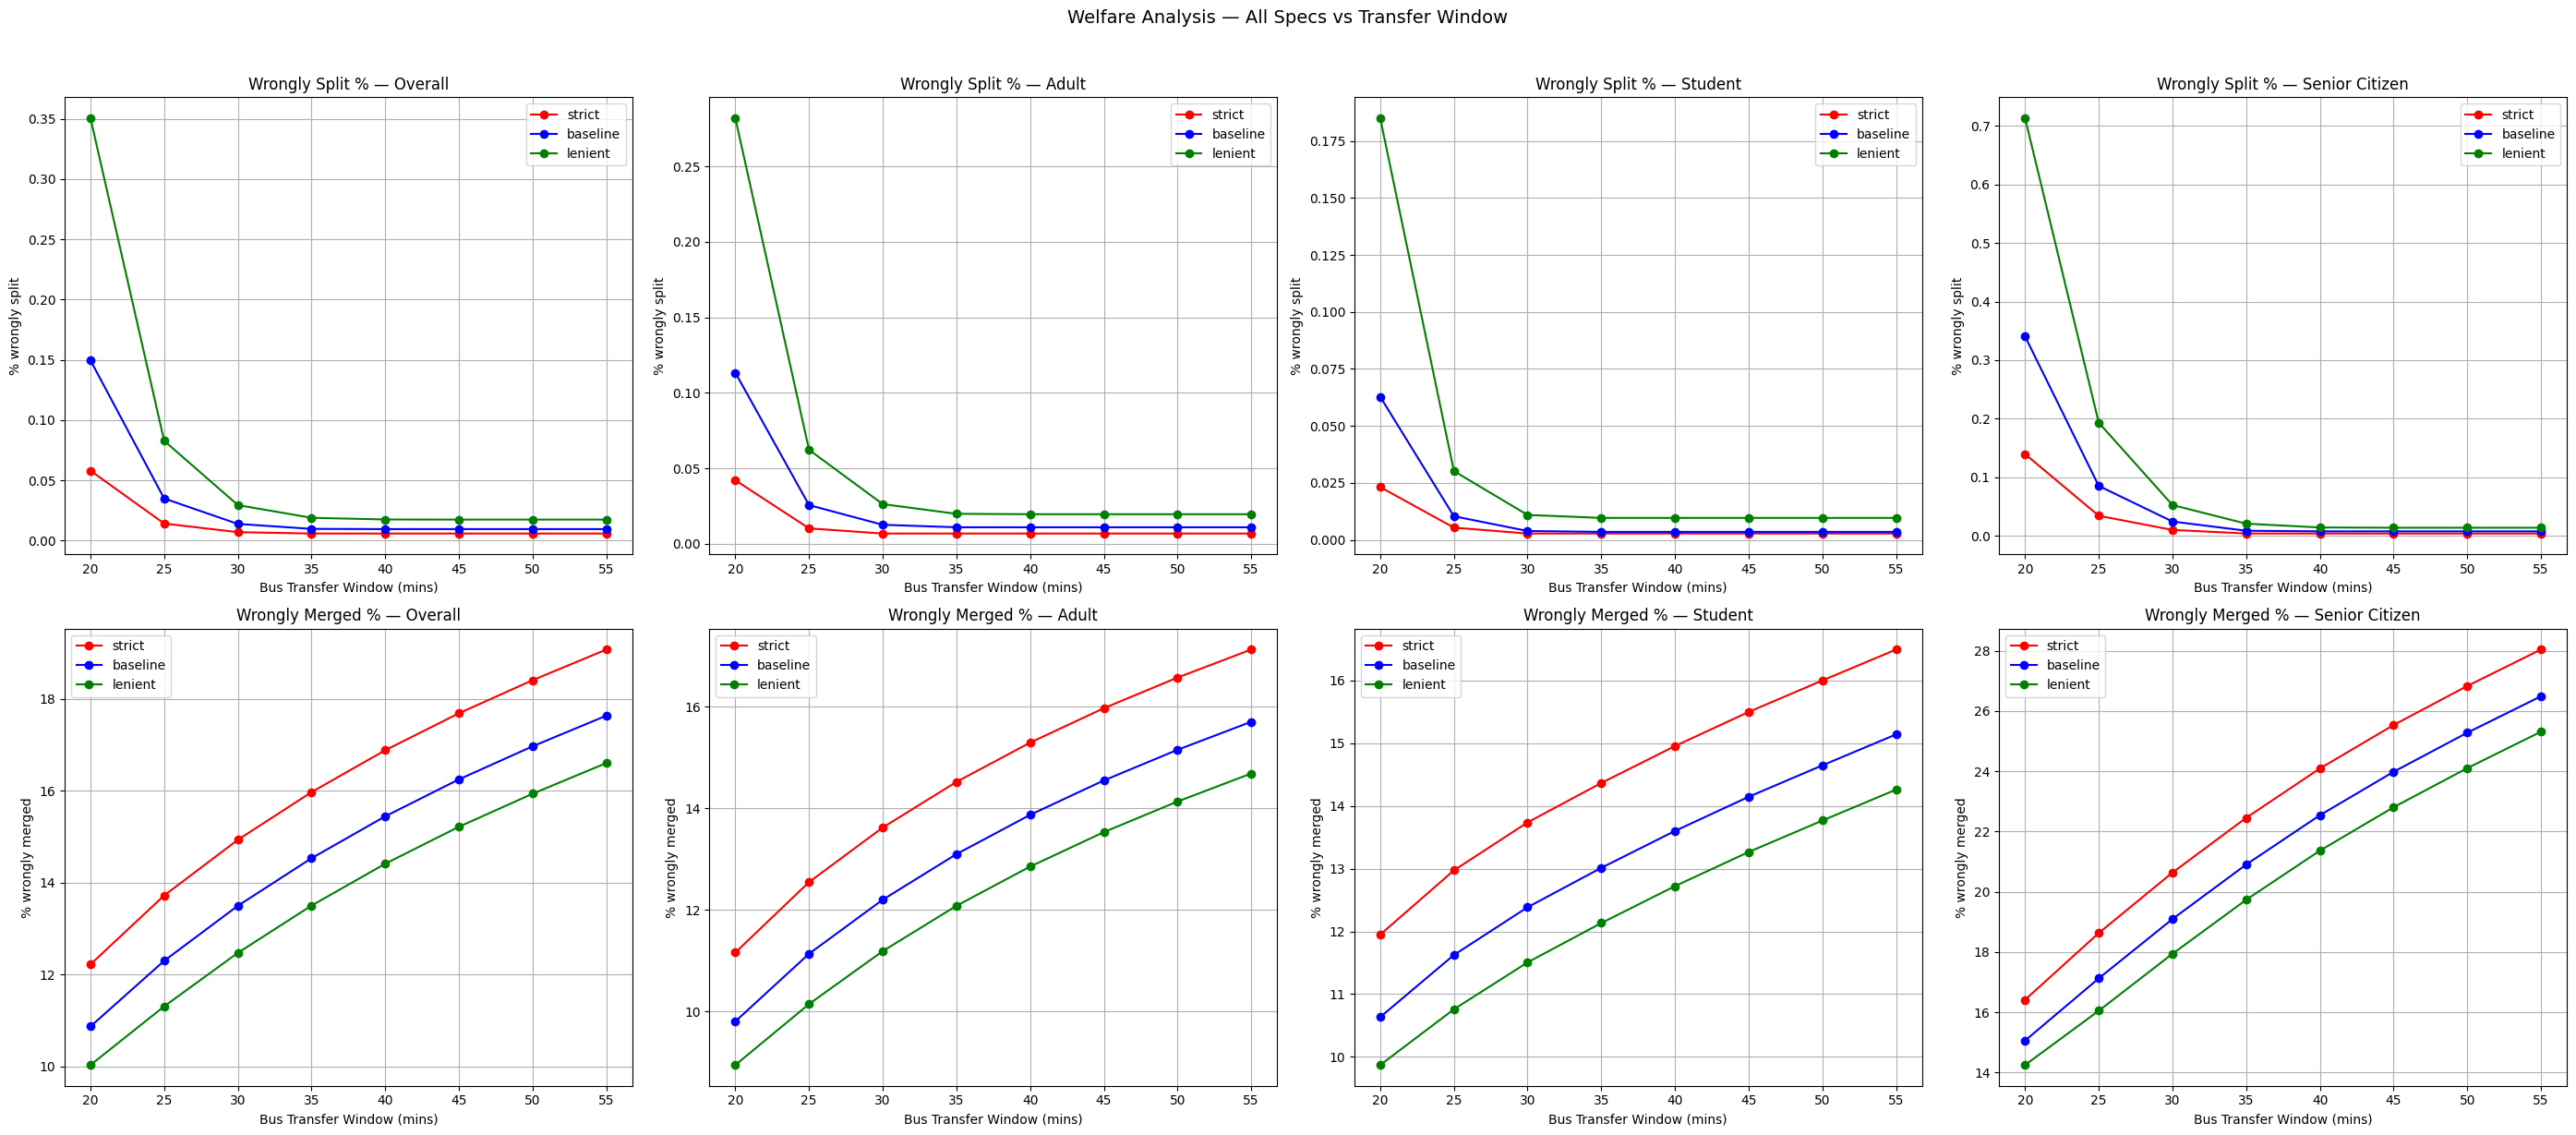

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(28, 12))

patrons = ['Overall', 'Adult', 'Student', 'Senior Citizen']
specs = ['strict', 'baseline', 'lenient']
colors = {'strict': 'red', 'baseline': 'blue', 'lenient': 'green'}

patrons_to_plot = ['Overall', 'Adult', 'Student', 'Senior Citizen']

for col, patron in enumerate(['Overall', 'Adult', 'Student', 'Senior Citizen']):
    for spec in specs:
        # get the right df
        df_spec = {
            'strict': results_strict_df,
            'baseline': results_baseline_df,
            'lenient': results_lenient_df
        }[spec]

        sub = df_spec[df_spec['patron'] == patron].sort_values('window_mins')

        # wrongly split — top row
        axes[0, col].plot(
            sub['window_mins'], sub['wrongly_split_pct'],
            marker='o', label=spec, color=colors[spec]
        )
        # wrongly merged — bottom row
        axes[1, col].plot(
            sub['window_mins'], sub['wrongly_merged_pct'],
            marker='o', label=spec, color=colors[spec]
        )

    axes[0, col].set_title(f'Wrongly Split % — {patron}')
    axes[0, col].set_xlabel('Bus Transfer Window (mins)')
    axes[0, col].set_ylabel('% wrongly split')
    axes[0, col].legend()
    axes[0, col].grid(True)

    axes[1, col].set_title(f'Wrongly Merged % — {patron}')
    axes[1, col].set_xlabel('Bus Transfer Window (mins)')
    axes[1, col].set_ylabel('% wrongly merged')
    axes[1, col].legend()
    axes[1, col].grid(True)

plt.suptitle('Welfare Analysis — All Specs vs Transfer Window', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Function for welfare analysis?

In [24]:
def get_welfare_summary(patron, window, spec):
    """
    Look up welfare results for a given patron category, transfer window, and classifier spec.

    Inputs:
    - patron: 'Overall', 'Adult', 'Student', 'Senior Citizen'
    - window: integer, one of 20, 25, 30, 35, 40, 45, 50, 55
    - spec: 'strict', 'baseline', 'lenient'

    Returns:
    - dict with split/merge error counts, unconditional rates, and conditional rates
    """
    row = final_results_df[
        (final_results_df['patron'] == patron) &
        (final_results_df['window_mins'] == window) &
        (final_results_df['spec'] == spec)
    ]

    if row.empty:
        return f"No data found for patron='{patron}', window={window}, spec='{spec}'"

    row = row.iloc[0]

    return {
        'spec':                     spec,
        'patron':                   patron,
        'window_mins':              window,
        'classifier_transfer_n':    row['classifier_transfer_n'],
        'classifier_new_journey_n': row['classifier_new_journey_n'],
        'window_transfer_n':        row['window_transfer_n'],
        'window_new_journey_n':     row['window_new_journey_n'],
        # split error: window too strict, breaks classifier-valid transfers → commuter overcharged
        'split_error_n':            row['wrongly_split_n'],
        'split_error_pct':          row['wrongly_split_pct'],          # % of all pairs
        'split_error_cond_pct':     row['wrongly_split_cond_pct'],     # % of classifier-said transfers
        # merge error: window too lenient, links classifier-separate journeys → fare undercharged
        'merge_error_n':            row['wrongly_merged_n'],
        'merge_error_pct':          row['wrongly_merged_pct'],         # % of all pairs
        'merge_error_cond_pct':     row['wrongly_merged_cond_pct'],    # % of classifier-said new journeys
    }

In [25]:
# example usage
print(get_welfare_summary('Adult', 35, 'baseline'))

{'spec': 'baseline', 'patron': 'Adult', 'window_mins': 35, 'classifier_transfer_n': np.int64(1134326), 'classifier_new_journey_n': np.int64(2195948), 'window_transfer_n': np.int64(1570138), 'window_new_journey_n': np.int64(1760136), 'split_error_n': np.int64(365), 'split_error_pct': np.float64(0.010960059142280786), 'split_error_cond_pct': np.float64(0.03217769847468894), 'merge_error_n': np.int64(436177), 'merge_error_pct': np.float64(13.097330730144128), 'merge_error_cond_pct': np.float64(19.86281095909375)}


In [26]:
# combine marginal results across all specs
marginal_df = pd.concat(
    [marginal_baseline_df, marginal_strict_df, marginal_lenient_df],
    ignore_index=True
)

marginal_df.to_csv('../data/welfare_marginal.csv', index=False)
print('Saved welfare_marginal.csv')
print(marginal_df.to_string())

Saved welfare_marginal.csv
        spec  window_from  window_to          patron  newly_linked_n  marginal_benefit_n  marginal_cost_n
0   baseline           20         25         Overall           73307                5443            67864
1   baseline           20         25         Student            5629                 283             5346
2   baseline           20         25           Adult           47311                2921            44390
3   baseline           20         25  Senior Citizen           20367                2239            18128
4   baseline           25         30         Overall           57866                1002            56864
5   baseline           25         30         Student            4144                  35             4109
6   baseline           25         30           Adult           35914                 434            35480
7   baseline           25         30  Senior Citizen           17808                 533            17275
8   baseline       

In [27]:
def get_marginal_summary(patron, spec, window_from):
    """
    Look up the marginal welfare effect of increasing the transfer window by 5 minutes.

    Inputs:
    - patron: 'Overall', 'Adult', 'Student', 'Senior Citizen'
    - spec: 'strict', 'baseline', 'lenient'
    - window_from: integer, one of 20, 25, 30, 35, 40, 45, 50
                   (returns the effect of moving from window_from to window_from + 5)

    Returns:
    - dict with newly linked pairs, marginal benefit (legitimate transfers rescued),
      and marginal cost (illegitimate links added)
    """
    window_to = window_from + 5

    row = marginal_df[
        (marginal_df['patron'] == patron) &
        (marginal_df['spec'] == spec) &
        (marginal_df['window_from'] == window_from) &
        (marginal_df['window_to'] == window_to)
    ]

    if row.empty:
        return f"No data found for patron='{patron}', spec='{spec}', window_from={window_from}"

    row = row.iloc[0]

    return {
        'spec':               spec,
        'patron':             patron,
        'window_from':        window_from,
        'window_to':          window_to,
        'newly_linked_n':     row['newly_linked_n'],       # total pairs newly linked by the larger window
        'marginal_benefit_n': row['marginal_benefit_n'],   # newly linked where classifier says transfer → legitimate rescue
        'marginal_cost_n':    row['marginal_cost_n'],      # newly linked where classifier says new journey → illegitimate link
    }

# example usage
print(get_marginal_summary('Adult', 'baseline', 35))

{'spec': 'baseline', 'patron': 'Adult', 'window_from': 35, 'window_to': 40, 'newly_linked_n': np.int64(25772), 'marginal_benefit_n': np.int64(0), 'marginal_cost_n': np.int64(25772)}


# Ignore below pls

### 45 min transfer window for bus-train, bus-bus rides. 15 min for train-train rides

In [ ]:
'''# define transfer window based on mode combination
df4['transfer_window_mins'] = np.where(
    (df4['TRNSPT_MODE_CD'] == 2) & (df4['next_TRNSPT_MODE_CD'] == 2),
    15,   # train to train
    45    # everything else
)

# flag: exceeds transfer window → new journey
df4['window_flag'] = (
    df4['time_gap_mins'] > df4['transfer_window_mins']
) | df4['time_gap_mins'].isna()'''

In [ ]:
'''# recompute journey sequence using window only
df4['window_journey_seq'] = (
    df4.groupby('CRD_NUM')['window_flag']
       .shift(fill_value=False)
       .groupby(df4['CRD_NUM'])
       .cumsum()
)'''

In [ ]:
'''# stage counts per journey
window_stage_counts = (
    df4.groupby(['CRD_NUM', 'window_journey_seq', 'PATRON_CATG_DESC_TXT'])
       .size()
       .reset_index(name='stage_count')
)

window_stage_counts['is_single_stage'] = window_stage_counts['stage_count'] == 1

window_summary = (
    window_stage_counts.groupby(['PATRON_CATG_DESC_TXT', 'is_single_stage'])
                       .size()
                       .unstack(fill_value=0)
                       .rename(columns={True: 'single_stage_journeys', False: 'multi_stage_journeys'})
)
window_summary['total_journeys'] = window_summary['single_stage_journeys'] + window_summary['multi_stage_journeys']
window_summary['multi_stage_%'] = (window_summary['multi_stage_journeys'] / window_summary['total_journeys'] * 100).round(2)

print(window_summary)'''

is_single_stage       multi_stage_journeys  single_stage_journeys  \
PATRON_CATG_DESC_TXT                                                
Adult                              1323381                2372249   
Senior Citizen                      351407                 436554   
Student                             217114                 351012   

is_single_stage       total_journeys  multi_stage_%  
PATRON_CATG_DESC_TXT                                 
Adult                        3695630          35.81  
Senior Citizen                787961          44.60  
Student                       568126          38.22  


#### toggling between different transfer windows for bus-train and bus-bus. (keep train-train constant at 15mins since not in the qn)

In [ ]:
'''
def compute_window_summary(df, bus_window, train_window=15):
    flag = (
        df['time_gap_mins'] > df['TRNSPT_MODE_CD'].map(
            lambda x: train_window if x == 2 else bus_window
        )
    ) | df['time_gap_mins'].isna()

    # assign flag as temp column to use in groupby
    df = df.assign(window_flag=flag)

    journey_seq = (
        df.groupby('CRD_NUM')['window_flag']
          .shift(fill_value=False)
          .groupby(df['CRD_NUM'])
          .cumsum()
    )

    stage_counts = (
        df.assign(window_journey_seq=journey_seq)
          .groupby(['CRD_NUM', 'window_journey_seq', 'PATRON_CATG_DESC_TXT'])
          .size()
          .reset_index(name='stage_count')
    )

    stage_counts['is_single_stage'] = stage_counts['stage_count'] == 1

    summ = (
        stage_counts.groupby(['PATRON_CATG_DESC_TXT', 'is_single_stage'])
                    .size()
                    .unstack(fill_value=0)
                    .rename(columns={True: 'single_stage_journeys', False: 'multi_stage_journeys'})
    )
    summ['total_journeys'] = summ['single_stage_journeys'] + summ['multi_stage_journeys']
    summ['multi_stage_%'] = (summ['multi_stage_journeys'] / summ['total_journeys'] * 100).round(2)
    return summ
    '''

In [ ]:
'''# WARNING: will take 9mins to run
# loop over range of bus windows
results = {}
for w in range(30, 65, 5):
    results[w] = compute_window_summary(df4, bus_window=w)
    print(f"Done: {w} min")'''

Done: 30 min
Done: 35 min
Done: 40 min
Done: 45 min
Done: 50 min
Done: 55 min
Done: 60 min


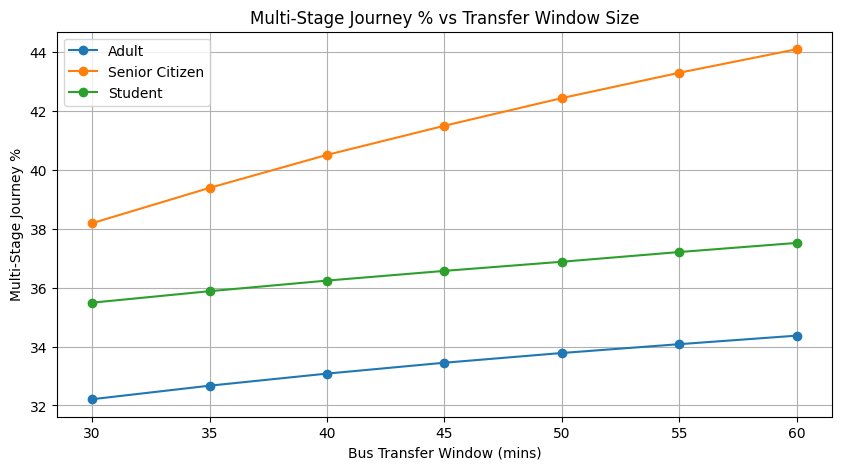

In [ ]:
'''# quick visualisation — multi_stage_% across window sizes per patron cat
patrons = ['Adult', 'Senior Citizen', 'Student']
windows = list(results.keys())

plt.figure(figsize=(10, 5))
for patron in patrons:
    pct = [results[w].loc[patron, 'multi_stage_%'] for w in windows]
    plt.plot(windows, pct, marker='o', label=patron)

plt.xlabel('Bus Transfer Window (mins)')
plt.ylabel('Multi-Stage Journey %')
plt.title('Multi-Stage Journey % vs Transfer Window Size')
plt.legend()
plt.grid(True)
plt.show()'''

## Ignore below because I used our classifier first then transfer window lol

Some Notes: 

- final flag from our classifier model is `final_termination_flag_spatial`. This marks the LAST RIDE of that journey. Every row belonging to the same joruney shares the same `final_journey_seq` number.
- in the below cost/benefit analysis
    - `multi_stage_journeys` = multiple rides classified into 1 journey. this is a journey count, not a ride count. UGWIM??
    - `single_stage_journeys` = only 1 ride in this journey

### Current classifier with no fixed transfer window

In [ ]:
'''# Our current classifier model, with no fixed transfer window allocated
# count stages per journey per commuter
journey_stage_counts = (
    df4.groupby(['CRD_NUM', 'final_journey_seq', 'PATRON_CATG_DESC_TXT']) # counts how many rides in a single journey
       .size()
       .reset_index(name='stage_count')
)

journey_stage_counts['is_single_stage'] = journey_stage_counts['stage_count'] == 1

# summary by patron category
summary = (
    journey_stage_counts.groupby(['PATRON_CATG_DESC_TXT', 'is_single_stage'])
                        .size()
                        .unstack(fill_value=0)
                        .rename(columns={True: 'single_stage_journeys', False: 'multi_stage_journeys'})
)
summary['total_journeys'] = summary['single_stage_journeys'] + summary['multi_stage_journeys']
summary['multi_stage_%'] = (summary['multi_stage_journeys'] / summary['total_journeys'] * 100).round(2)

print(summary)'''

is_single_stage       multi_stage_journeys  single_stage_journeys  \
PATRON_CATG_DESC_TXT                                                
Adult                              1064242                3041842   
Senior Citizen                      240716                 740830   
Student                             171499                 461883   

is_single_stage       total_journeys  multi_stage_%  
PATRON_CATG_DESC_TXT                                 
Adult                        4106084          25.92  
Senior Citizen                981546          24.52  
Student                       633382          27.08  


### Classifier with 45 minute transfer window imposed

In [ ]:
'''# impose 45-min hard cap on top of existing classifier
df4['w45_flag'] = (
    df4['final_termination_flag_spatial'] |
    (df4['time_gap_mins'] > 45)
)
# recompute journey sequence with 45-min window
df4['w45_journey_seq'] = (
    df4.groupby('CRD_NUM')['w45_flag']
       .shift(fill_value=False)
       .groupby(df4['CRD_NUM'])
       .cumsum()
)'''

In [ ]:
'''# count stages per journey
w45_stage_counts = (
    df4.groupby(['CRD_NUM', 'w45_journey_seq', 'PATRON_CATG_DESC_TXT'])
       .size()
       .reset_index(name='stage_count')
)

w45_stage_counts['is_single_stage'] = w45_stage_counts['stage_count'] == 1

w45_summary = (
    w45_stage_counts.groupby(['PATRON_CATG_DESC_TXT', 'is_single_stage'])
                    .size()
                    .unstack(fill_value=0)
                    .rename(columns={True: 'single_stage_journeys', False: 'multi_stage_journeys'})
)
w45_summary['total_journeys'] = w45_summary['single_stage_journeys'] + w45_summary['multi_stage_journeys']
w45_summary['multi_stage_%'] = (w45_summary['multi_stage_journeys'] / w45_summary['total_journeys'] * 100).round(2)

print(w45_summary)'''

is_single_stage       multi_stage_journeys  single_stage_journeys  \
PATRON_CATG_DESC_TXT                                                
Adult                              1064242                3041842   
Senior Citizen                      240716                 740830   
Student                             171499                 461883   

is_single_stage       total_journeys  multi_stage_%  
PATRON_CATG_DESC_TXT                                 
Adult                        4106084          25.92  
Senior Citizen                981546          24.52  
Student                       633382          27.08  


#### How did the additional 45min transfer window affect the classifier?

In [ ]:
'''# how many rows would the 45min window catch that the existing classifier doesn't?
new_flags = (
    (df4['final_termination_flag_spatial'] == False) &
    (df4['time_gap_mins'] > 45)
)
print(new_flags.sum())
# Gives 0! current classifier is already stricter than a 45-min window!'''

0


In [ ]:
'''# among rows classifier says are transfers, what's the time_gap distribution?
transfers = df4[df4['final_termination_flag_spatial'] == False]
print(transfers['time_gap_mins'].describe())
print(f"\n% with time_gap > 30: {(transfers['time_gap_mins'] > 30).mean()*100:.2f}%")
print(f"% with time_gap > 45: {(transfers['time_gap_mins'] > 45).mean()*100:.2f}%")
print(f"% with time_gap > 60: {(transfers['time_gap_mins'] > 60).mean()*100:.2f}%")'''

count    1.718541e+06
mean     5.787921e+00
std      4.991546e+00
min     -1.760000e+01
25%      2.250000e+00
50%      3.950000e+00
75%      7.800000e+00
max      3.598333e+01
Name: time_gap_mins, dtype: float64

% with time_gap > 30: 0.02%
% with time_gap > 45: 0.00%
% with time_gap > 60: 0.00%


Implement the 45-minute Window on our Current Classifier

Adjust the window and Observe Increases and Decreases across Different Patron Categories (maybe regions too?)
- Varying the Transfer Window in 5-minute Increments within a Range (e.g., 30 to 60 minutes)
- For each Increment, Consecutive Journey Stages are Reclassified under the Revised Transfer Window

Benefit: 
- Number of Additional Legitimate Journeys that become Eligible for a Single-Journey Fare under an Updated Longer Transfer Window
- MB: Increase in Number and Proportion of Legitimate Multi-Leg Journeys that Newly Qualify for a Single-Journey Fare when the Window is Increased (e.g., in 5-minute increments)


Cost: 
- Number of Distinct Standalone Journeys that may be Incorrectly Merged into a Single Transfer-Linked Journey under the Extended Window, Resulting in Potential Fare Undercharging
- Calculate the Fare Loss (in LTA’s point of view) from Journeys that are Incorrectly Merged